In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
df=pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print(df.isnull().sum())
current_year = datetime.datetime.now().year
df['Car_Age']=current_year-df['Year']
df.drop(['Car_Name','Year'],axis=1,inplace=True)
df=pd.get_dummies(df,drop_first=True)
df.head()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Separate features (X) and target variable (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions and evaluate performance
predictions = model.predict(X_test)
print("R2 Score:", metrics.r2_score(y_test, predictions))
print("MAE:", metrics.mean_absolute_error(y_test, predictions))

R2 Score: 0.9543495113792257
MAE: 0.6702934426229515


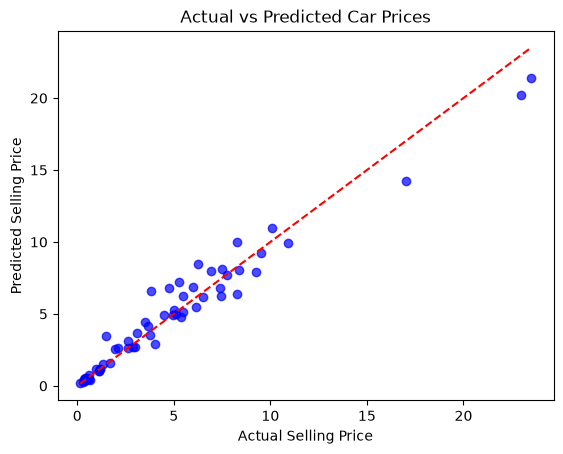

In [6]:
plt.scatter(y_test, predictions, alpha=0.7, color='blue')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [7]:
# Predict for a single test sample
sample_car = X_test.iloc[0:1]
actual_price = y_test.iloc[0]
predicted_price = model.predict(sample_car)[0]

print(f"Actual Price: {actual_price:.2f} Lakhs")
print(f"Predicted Price: {predicted_price:.2f} Lakhs")

Actual Price: 0.35 Lakhs
Predicted Price: 0.45 Lakhs


In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn